# Brain Tumor 3D Segmentation with MONAI

Import required libraries and packages

In [1]:
import os, shutil, tempfile, time, random, gc, warnings, glob
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'        # Fixes a warning from PyTorch
import torch
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Optional, Literal
from dataclasses import dataclass
from pathlib import Path

from monai.apps import DecathlonDataset
from monai.config import print_config
from monai.data import DataLoader, decollate_batch
from monai.handlers.utils import from_engine
from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric
from monai.networks.nets import SegResNet
from monai.transforms import (
    Activations,
    Activationsd,
    AsDiscrete,
    AsDiscreted,
    Compose,
    Invertd,
    LoadImaged,
    MapTransform,
    NormalizeIntensityd,
    Orientationd,
    RandFlipd,
    RandScaleIntensityd,
    RandShiftIntensityd,
    RandSpatialCropd,
    Spacingd,
    EnsureTyped,
    EnsureChannelFirstd,
)

from monai.utils import set_determinism
import onnxruntime
from tqdm import tqdm

# Make plots have guidelines
plt.style.use('ggplot')

# Squash Python warnings
warnings.filterwarnings('ignore')

# Enable Python's Garbage Collector
gc.collect()

2026-02-26 03:10:37.344202440 [W:onnxruntime:Default, device_discovery.cc:211 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:91 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"
<frozen importlib._bootstrap_external>:1325: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-02-26 03:10:43.833596: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


752

In [2]:
SEED = 42
ROOT_DIR = '../monai'
MAX_EPOCHS = 50
VAL_INTERVAL = 1
VAL_AMP = True
NUM_WORKERS = 4

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
#set_determinism(SEED)

# When running on CuDNN backend, it is recommended to set these two options
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False
torch.set_float32_matmul_precision('medium')

In [4]:
class ConvertToMultiChannelBasedOnBratsClassesd(MapTransform):
    '''
    Convert labels to multi channels based on brats classes:
    label 1 is the peritumoral edema
    label 2 is the GD-enhancing tumor
    label 3 is the necrotic and non-enhancing tumor core
    The possible classes are TC (Tumor core), WT (Whole tumor)
    and ET (Enhancing tumor).
    '''

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            result = []
            # merge label 2 and label 3 to construct TC
            result.append(torch.logical_or(d[key] == 2, d[key] == 3))
            # merge labels 1, 2 and 3 to construct WT
            result.append(torch.logical_or(torch.logical_or(d[key] == 2, d[key] == 3), d[key] == 1))
            # label 2 is ET
            result.append(d[key] == 2)
            d[key] = torch.stack(result, axis=0).float()
        return d

In [5]:
train_transform = Compose(
    [
        # load 4 Nifti images and stack them together
        LoadImaged(keys=['image', 'label']),
        EnsureChannelFirstd(keys='image'),
        EnsureTyped(keys=['image', 'label']),
        ConvertToMultiChannelBasedOnBratsClassesd(keys='label'),
        Orientationd(keys=['image', 'label'], axcodes='RAS'),
        Spacingd(
            keys=['image', 'label'],
            pixdim=(1.0, 1.0, 1.0),
            mode=('bilinear', 'nearest'),
        ),
        RandSpatialCropd(keys=['image', 'label'], roi_size=[128, 128, 64], random_size=False),
        RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=0),
        RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=1),
        RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=2),
        NormalizeIntensityd(keys='image', nonzero=True, channel_wise=True),
        RandScaleIntensityd(keys='image', factors=0.1, prob=1.0),
        RandShiftIntensityd(keys='image', offsets=0.1, prob=1.0),
    ]
)
val_transform = Compose(
    [
        LoadImaged(keys=['image', 'label']),
        EnsureChannelFirstd(keys='image'),
        EnsureTyped(keys=['image', 'label']),
        ConvertToMultiChannelBasedOnBratsClassesd(keys='label'),
        Orientationd(keys=['image', 'label'], axcodes='RAS'),
        Spacingd(
            keys=['image', 'label'],
            pixdim=(1.0, 1.0, 1.0),
            mode=('bilinear', 'nearest'),
        ),
        NormalizeIntensityd(keys='image', nonzero=True, channel_wise=True),
    ]
)

In [6]:
train_ds = DecathlonDataset(
    root_dir=ROOT_DIR,
    task='Task01_BrainTumour',
    transform=train_transform,
    section='training',
    download=False,
    cache_rate=0.0,
    num_workers=NUM_WORKERS,
)
train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=4)

val_ds = DecathlonDataset(
    root_dir=ROOT_DIR,
    task='Task01_BrainTumour',
    transform=val_transform,
    section='validation',
    download=False,
    cache_rate=0.0,
    num_workers=NUM_WORKERS,
)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=NUM_WORKERS)

image shape: torch.Size([4, 240, 240, 155])


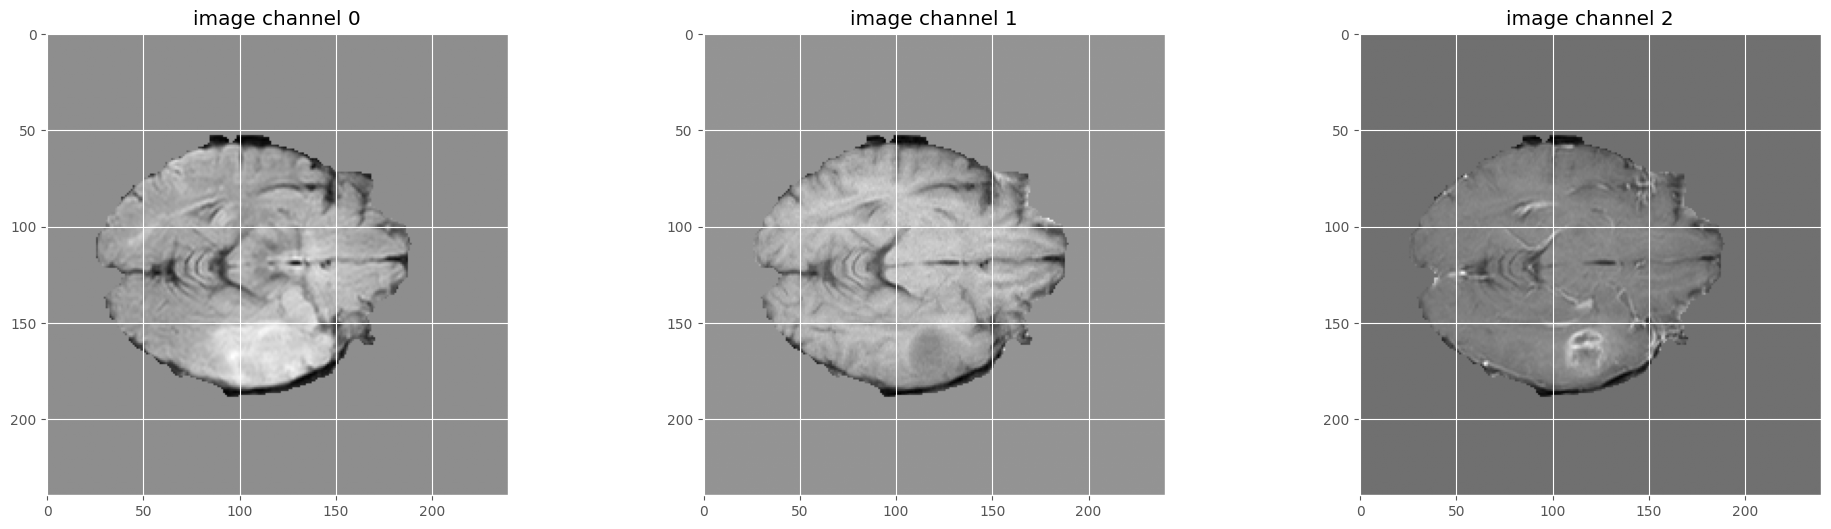

label shape: torch.Size([3, 240, 240, 155])


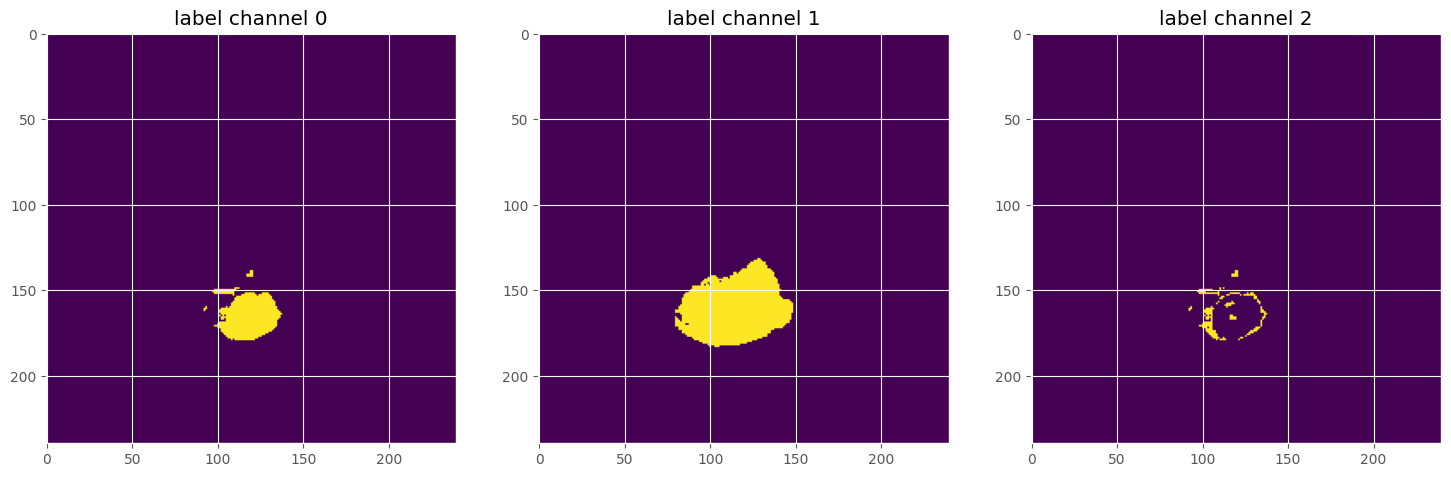

In [11]:
# Pick one image and visualize the different channels
val_data_example = val_ds[2]
print(f'image shape: {val_data_example['image'].shape}')
plt.figure('image', (24, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.title(f'image channel {i}')
    plt.imshow(val_data_example['image'][i, :, :, 60].detach().cpu(), cmap='gray')
plt.show()

# Visualize the segmentation labels
print(f'label shape: {val_data_example['label'].shape}')
plt.figure('label', (18, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.title(f'label channel {i}')
    plt.imshow(val_data_example['label'][i, :, :, 60].detach().cpu())
plt.show()

In [8]:
# standard PyTorch program style: create SegResNet, DiceLoss and Adam optimizer
model = SegResNet(
    blocks_down=[1, 2, 2, 4],
    blocks_up=[1, 1, 1],
    init_filters=16,
    in_channels=4,
    out_channels=3,
    dropout_prob=0.2).to(DEVICE)
loss_function = DiceLoss(smooth_nr=0, smooth_dr=1e-5, squared_pred=True, to_onehot_y=False, sigmoid=True)
optimizer = torch.optim.Adam(model.parameters(), 1e-4, weight_decay=1e-5)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

dice_metric = DiceMetric(include_background=True, reduction='mean')
dice_metric_batch = DiceMetric(include_background=True, reduction='mean_batch')

post_trans = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])


# define inference method
def inference(input):
    def _compute(input):
        return sliding_window_inference(
            inputs=input,
            #roi_size=(240, 240, 160),
            roi_size = [128, 128, 64],
            sw_batch_size=4,
            predictor=model,
            overlap=0.5,
        )

    if VAL_AMP:
        with torch.autocast('cuda'):
            return _compute(input)
    else:
        return _compute(input)


# use amp to accelerate training
scaler = torch.GradScaler('cuda')
# enable cuDNN benchmark
torch.backends.cudnn.benchmark = True

In [11]:
best_metric = -1
best_metric_epoch = -1
best_metrics_epochs_and_time = [[], [], []]
epoch_loss_values = []
metric_values = []
metric_values_tc = []
metric_values_wt = []
metric_values_et = []

total_start = time.time()
for epoch in range(MAX_EPOCHS):
    epoch_start = time.time()
    print('-' * 10)
    print(f'epoch {epoch + 1}/{MAX_EPOCHS}')
    model.train()
    epoch_loss = 0
    step = 0
    for batch_data in train_loader:
        step_start = time.time()
        step += 1
        inputs, labels = (
            batch_data['image'].to(DEVICE),
            batch_data['label'].to(DEVICE),
        )
        optimizer.zero_grad()
        with torch.autocast('cuda'):
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        epoch_loss += loss.item()
        print(
            f'{step}/{len(train_ds) // train_loader.batch_size}'
            f', train_loss: {loss.item():.4f}'
            f', step time: {(time.time() - step_start):.4f}'
        )
    lr_scheduler.step()
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f'epoch {epoch + 1} average loss: {epoch_loss:.4f}')

    if (epoch + 1) % VAL_INTERVAL == 0:
        model.eval()
        with torch.no_grad():
            for val_data in val_loader:
                val_inputs, val_labels = (
                    val_data['image'].to(DEVICE),
                    val_data['label'].to(DEVICE),
                )
                val_outputs = inference(val_inputs)
                val_outputs = [post_trans(i) for i in decollate_batch(val_outputs)]
                dice_metric(y_pred=val_outputs, y=val_labels)
                dice_metric_batch(y_pred=val_outputs, y=val_labels)

            metric = dice_metric.aggregate().item()
            metric_values.append(metric)
            metric_batch = dice_metric_batch.aggregate()
            metric_tc = metric_batch[0].item()
            metric_values_tc.append(metric_tc)
            metric_wt = metric_batch[1].item()
            metric_values_wt.append(metric_wt)
            metric_et = metric_batch[2].item()
            metric_values_et.append(metric_et)
            dice_metric.reset()
            dice_metric_batch.reset()

            if metric > best_metric:
                best_metric = metric
                best_metric_epoch = epoch + 1
                best_metrics_epochs_and_time[0].append(best_metric)
                best_metrics_epochs_and_time[1].append(best_metric_epoch)
                best_metrics_epochs_and_time[2].append(time.time() - total_start)
                torch.save(
                    model.state_dict(),
                    os.path.join(ROOT_DIR, 'best_metric_model.pth'),
                )
                print('saved new best metric model')
            print(
                f'current epoch: {epoch + 1} current mean dice: {metric:.4f}'
                f' tc: {metric_tc:.4f} wt: {metric_wt:.4f} et: {metric_et:.4f}'
                f'\nbest mean dice: {best_metric:.4f}'
                f' at epoch: {best_metric_epoch}'
            )
    print(f'time consuming of epoch {epoch + 1} is: {(time.time() - epoch_start):.4f}')
total_time = time.time() - total_start

----------
epoch 1/50
1/388, train_loss: 0.6213, step time: 0.0898
2/388, train_loss: 1.0000, step time: 0.0748
3/388, train_loss: 0.8200, step time: 0.0753
4/388, train_loss: 0.8621, step time: 0.0749
5/388, train_loss: 0.7543, step time: 0.0746
6/388, train_loss: 0.7725, step time: 0.0720
7/388, train_loss: 0.5738, step time: 0.0719
8/388, train_loss: 0.7332, step time: 0.0757
9/388, train_loss: 0.7619, step time: 0.0723
10/388, train_loss: 0.8066, step time: 0.0719
11/388, train_loss: 0.6458, step time: 0.0713
12/388, train_loss: 0.7909, step time: 0.0789
13/388, train_loss: 0.5795, step time: 0.0724
14/388, train_loss: 0.9657, step time: 0.0719
15/388, train_loss: 0.8026, step time: 0.0719
16/388, train_loss: 0.9889, step time: 0.0722
17/388, train_loss: 0.9977, step time: 0.0724
18/388, train_loss: 0.9761, step time: 0.0726
19/388, train_loss: 0.9939, step time: 0.0753
20/388, train_loss: 0.9971, step time: 0.0739
21/388, train_loss: 0.5848, step time: 0.0773
22/388, train_loss: 1

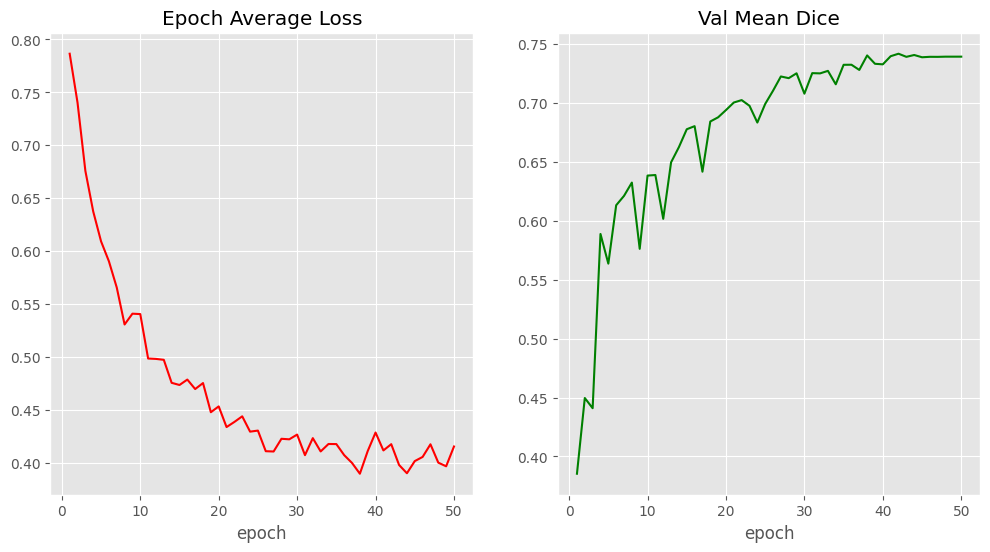

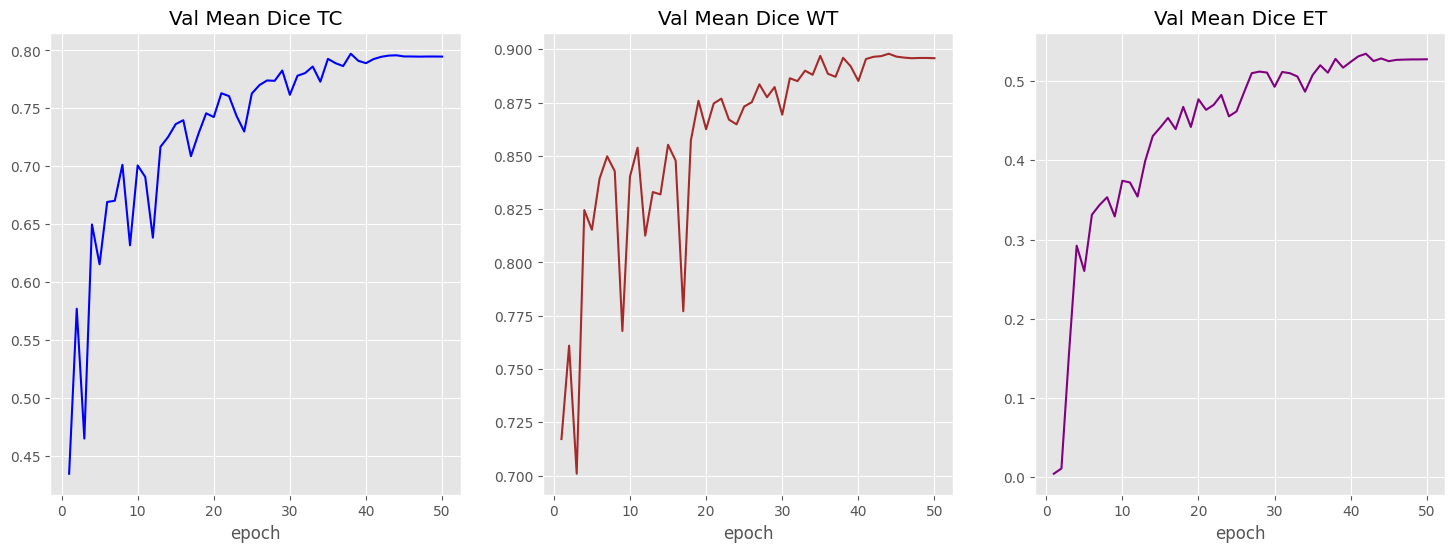

In [12]:
plt.figure("train", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Epoch Average Loss")
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.xlabel("epoch")
plt.plot(x, y, color="red")
plt.subplot(1, 2, 2)
plt.title("Val Mean Dice")
x = [VAL_INTERVAL * (i + 1) for i in range(len(metric_values))]
y = metric_values
plt.xlabel("epoch")
plt.plot(x, y, color="green")
plt.show()

plt.figure("train", (18, 6))
plt.subplot(1, 3, 1)
plt.title("Val Mean Dice TC")
x = [VAL_INTERVAL * (i + 1) for i in range(len(metric_values_tc))]
y = metric_values_tc
plt.xlabel("epoch")
plt.plot(x, y, color="blue")
plt.subplot(1, 3, 2)
plt.title("Val Mean Dice WT")
x = [VAL_INTERVAL * (i + 1) for i in range(len(metric_values_wt))]
y = metric_values_wt
plt.xlabel("epoch")
plt.plot(x, y, color="brown")
plt.subplot(1, 3, 3)
plt.title("Val Mean Dice ET")
x = [VAL_INTERVAL * (i + 1) for i in range(len(metric_values_et))]
y = metric_values_et
plt.xlabel("epoch")
plt.plot(x, y, color="purple")
plt.show()